In [31]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
df=pd.read_csv("Algerian_forest_fires_dataset.csv",header=0)

In [3]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [4]:
df.loc[:123,"Region"]=0
df.loc[123:,"Region"]=1

In [5]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [6]:
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    object 
 1   month        244 non-null    object 
 2   year         244 non-null    object 
 3   Temperature  244 non-null    object 
 4    RH          244 non-null    object 
 5    Ws          244 non-null    object 
 6   Rain         244 non-null    object 
 7   FFMC         244 non-null    object 
 8   DMC          244 non-null    object 
 9   DC           244 non-null    object 
 10  ISI          244 non-null    object 
 11  BUI          244 non-null    object 
 12  FWI          244 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       244 non-null    float64
dtypes: float64(1), object(14)
memory usage: 28.7+ KB


In [8]:
df[df["day"]=='day']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [9]:
df=df.drop(index=122)

In [10]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [11]:
df[['day','month', 'year','Temperature',' RH',' Ws']]=df[['day','month', 'year','Temperature',' RH',' Ws']].astype(int)

In [12]:
features=[col for col in df.columns if df[col].dtype=="O"]
features

['Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ']

In [13]:
for col in features:
    if col!='Classes  ':
        df[col]=df[col].astype(float);
df["Region"]=df["Region"].astype(int)

In [14]:
df.columns=df.columns.str.strip()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.4+ KB


In [16]:
df.to_csv("Algerian_forest_fires_clean_dataset.csv",index=False)

EDA


In [17]:
df1=df.drop(["day","month","year"],axis=1)

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    object 
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 24.7+ KB


In [19]:
df1["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [20]:
#encoding
df1["Classes"]=np.where(df1["Classes"].str.contains("not fire"),0,1);

In [21]:
df1["Classes"]=df1["Classes"].astype(int)

feature enggg and selection

In [22]:
X=df1.drop(["FWI"],axis=1)
y=df1["FWI"];

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42)

In [24]:
X_train.shape

(182, 11)

In [25]:
X_test.shape

(61, 11)

In [26]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

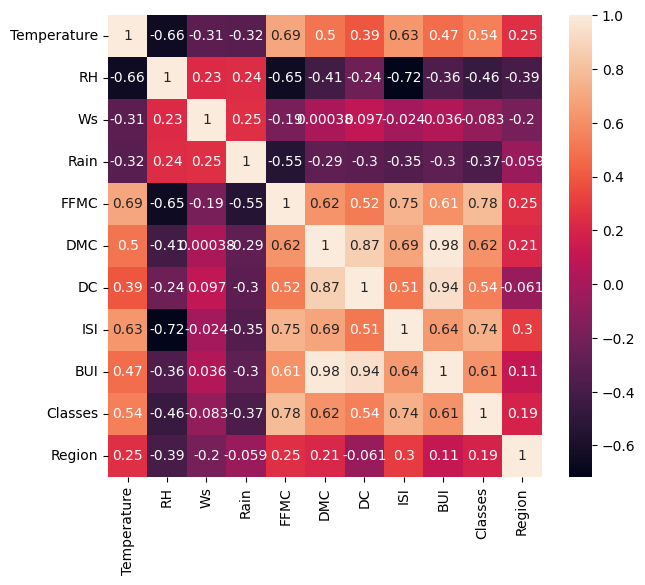

In [38]:
plt.figure(figsize=(7,6))
cor=X_train.corr()
sns.heatmap(cor,annot=True)

In [55]:
def corelation(dataset,threshold):
    ans=set()
    mat=dataset.corr()
    for i in range(len(mat.columns)):
        for j in range(i):
            if abs(mat.iloc[i,j])>threshold:
                col_name=mat.columns[i]
                ans.add(col_name)
    return ans;

col_del=corelation(X_train,.85)
X_train=X_train.drop(col_del,axis=1)
X_test=X_test.drop(col_del,axis=1)


standardization


In [59]:
from sklearn.preprocessing import StandardScaler;
scaler=StandardScaler()
X_train_std=scaler.fit_transform(X_train)
X_test_std=scaler.transform(X_test)

<Axes: title={'center': 'after'}>

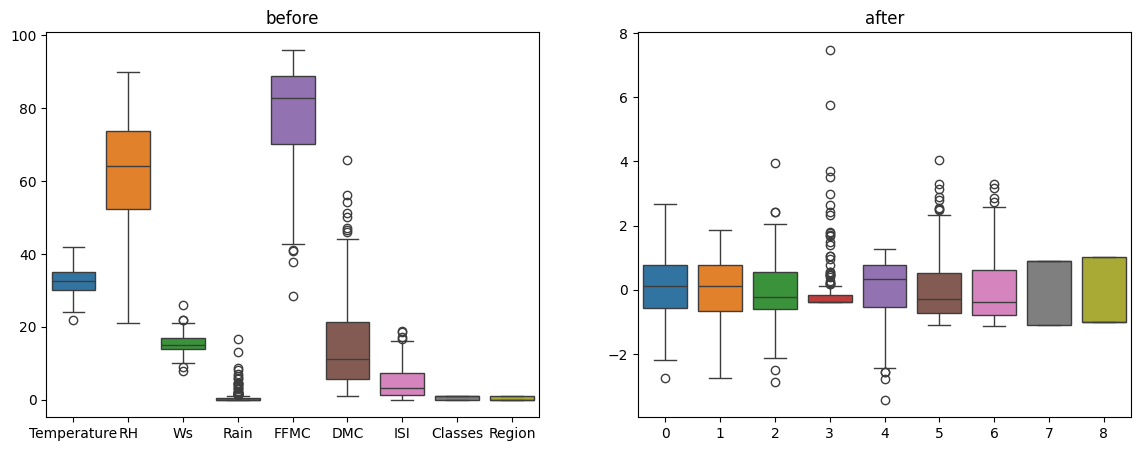

In [67]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.title("before")
sns.boxplot(data=X_train)
plt.subplot(1,2,2)
plt.title("after")
sns.boxplot(data=X_train_std)

## model training

mean absolute error-->  0.5468236465249986
r2 score-->  0.9847657384266951


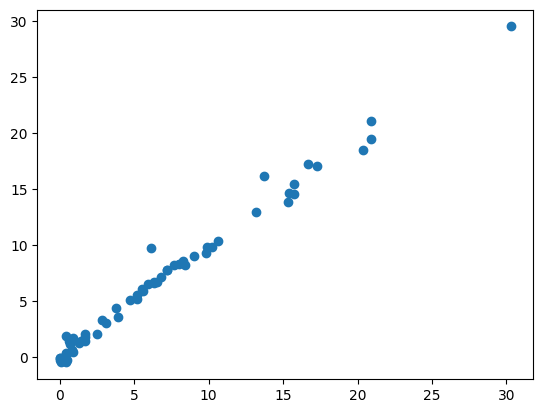

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error;
from sklearn.metrics import r2_score;
regression=LinearRegression(n_jobs=-1);
model=regression.fit(X_train_std,y_train)
y_pred=model.predict(X_test_std)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean absolute error--> ",mae)
print("r2 score--> ",score)
plt.scatter(y_test,y_pred)

mean absolute error-->  1.133175994914409
r2 score-->  0.9492020263112388


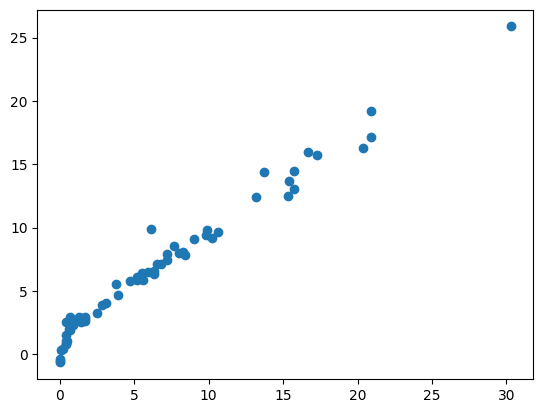

In [92]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error;
from sklearn.metrics import r2_score;
laso=Lasso();
model=laso.fit(X_train_std,y_train)
y_pred=model.predict(X_test_std)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean absolute error--> ",mae)
print("r2 score--> ",score)
plt.scatter(y_test,y_pred)

mean absolute error-->  0.5642305340105692
r2 score-->  0.9842993364555513


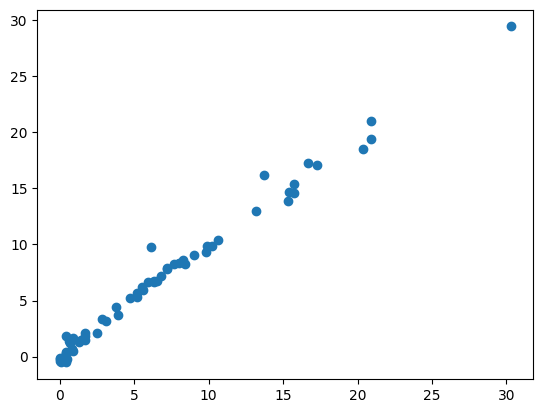

In [94]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error;
from sklearn.metrics import r2_score;
rr=Ridge();
model=rr.fit(X_train_std,y_train)
y_pred=model.predict(X_test_std)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean absolute error--> ",mae)
print("r2 score--> ",score)
plt.scatter(y_test,y_pred)

mean absolute error-->  1.8822353634896005
r2 score-->  0.8753460589519703


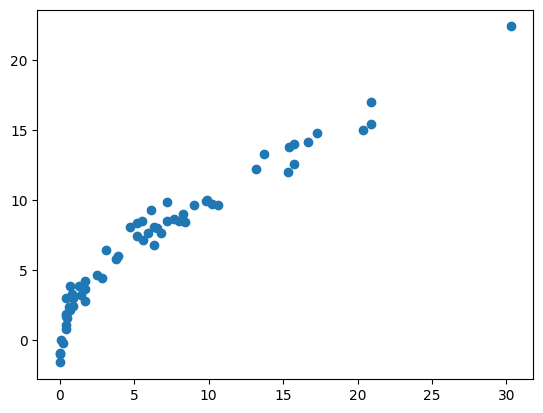

In [95]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error;
from sklearn.metrics import r2_score;
elastic=ElasticNet();
model=elastic.fit(X_train_std,y_train)
y_pred=model.predict(X_test_std)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mean absolute error--> ",mae)
print("r2 score--> ",score)
plt.scatter(y_test,y_pred)

# hyperparameter

In [97]:
from sklearn.linear_model import RidgeCV